# 🔗 Hands-On Bab 7 — Jaringan Dinamis
### Analisis Jaringan Sosial: Konsep, Metode, dan Aplikasi

Notebook ini mereproduksi representasi jaringan dinamis berbasis snapshot, perhitungan **temporal strength**, **weighted reciprocity**, dan studi kasus tim proyek dua bulan dari buku — lengkap dengan **Latihan Soal Bab 7**.

In [1]:
!pip install -q networkx matplotlib
import networkx as nx
import matplotlib.pyplot as plt

## 7.2.1 Representasi Berbasis Snapshot

Kita bangun dua snapshot jaringan (bulan 1 dan bulan 2) sesuai Contoh 7.4 di buku, lalu identifikasi perubahan strukturnya.

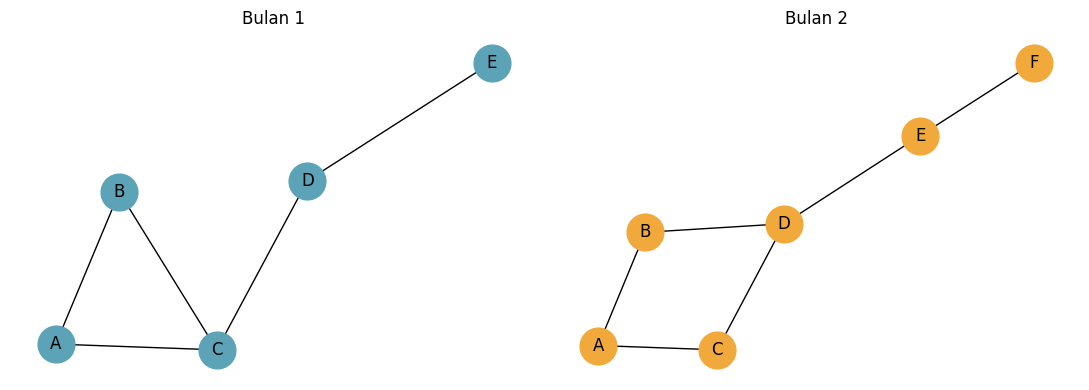

In [2]:
# Bulan 1
G_t1 = nx.Graph()
G_t1.add_nodes_from(["A","B","C","D","E"])
G_t1.add_edges_from([("A","B"), ("A","C"), ("B","C"), ("C","D"), ("D","E")])

# Bulan 2
G_t2 = nx.Graph()
G_t2.add_nodes_from(["A","B","C","D","E","F"])
G_t2.add_edges_from([("A","B"), ("A","C"), ("B","D"), ("C","D"), ("D","E"), ("E","F")])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
pos = nx.spring_layout(G_t2, seed=1)
nx.draw(G_t1, pos, ax=axes[0], with_labels=True, node_color="#5CA3B8", node_size=700)
axes[0].set_title("Bulan 1")
nx.draw(G_t2, pos, ax=axes[1], with_labels=True, node_color="#F2A93B", node_size=700)
axes[1].set_title("Bulan 2")
plt.tight_layout()
plt.show()

In [3]:
# Identifikasi perubahan struktur secara otomatis
simpul_baru = set(G_t2.nodes()) - set(G_t1.nodes())
simpul_hilang = set(G_t1.nodes()) - set(G_t2.nodes())
sisi_baru = set(G_t2.edges()) - set(G_t1.edges())
sisi_hilang = set(G_t1.edges()) - set(G_t2.edges())

print("Simpul baru  :", simpul_baru, " (buku: F)")
print("Simpul hilang:", simpul_hilang if simpul_hilang else "(tidak ada)")
print("Sisi baru    :", sisi_baru, " (buku: (B,D) dan (E,F))")
print("Sisi hilang  :", sisi_hilang, " (buku: (B,C))")

# Perubahan degree tiap simpul
print("\nPerubahan degree per simpul:")
for node in G_t2.nodes():
    d1 = G_t1.degree(node) if node in G_t1 else 0
    d2 = G_t2.degree(node)
    print(f"  {node}: {d1} -> {d2}  (\u0394 = {d2-d1:+d})")

Simpul baru  : {'F'}  (buku: F)
Simpul hilang: (tidak ada)
Sisi baru    : {('E', 'F'), ('B', 'D')}  (buku: (B,D) dan (E,F))
Sisi hilang  : {('B', 'C')}  (buku: (B,C))

Perubahan degree per simpul:
  A: 2 -> 2  (Δ = +0)
  B: 2 -> 2  (Δ = +0)
  C: 3 -> 2  (Δ = -1)
  D: 2 -> 3  (Δ = +1)
  E: 1 -> 2  (Δ = +1)
  F: 0 -> 1  (Δ = +1)


## 7.5.1 Temporal Strength

Reproduksi Contoh 7.3: simpul A dengan relasi berbobot ke B, C, D yang berubah dari waktu t ke t+1.

In [4]:
relasi_t = {"B": 2, "C": 3, "D": 1}
relasi_t1 = {"B": 3, "C": 1, "D": 2}

S_A_t = sum(relasi_t.values())
S_A_t1 = sum(relasi_t1.values())

print(f"S_A(t)   = {' + '.join(map(str, relasi_t.values()))} = {S_A_t}   (buku: 6)")
print(f"S_A(t+1) = {' + '.join(map(str, relasi_t1.values()))} = {S_A_t1}   (buku: 6)")
print(f"\nDelta S_A = {S_A_t1 - S_A_t}  --> total strength SAMA, tapi komposisi relasi berubah")
print("(pola interaksi bergeser meskipun total aktivitas stabil)")

S_A(t)   = 2 + 3 + 1 = 6   (buku: 6)
S_A(t+1) = 3 + 1 + 2 = 6   (buku: 6)

Delta S_A = 0  --> total strength SAMA, tapi komposisi relasi berubah
(pola interaksi bergeser meskipun total aktivitas stabil)


## 7.5.2 Weighted Reciprocity

Hitung keseimbangan intensitas relasi dua arah antara dua simpul.

In [5]:
def weighted_reciprocity(w_ij, w_ji):
    return min(w_ij, w_ji) / max(w_ij, w_ji)

kasus = [
    ("Seimbang sepenuhnya", 5, 5),
    ("Tidak seimbang", 8, 2),
    ("Sepihak (searah)", 6, 0.001),  # mendekati 0
]

for nama, w_ij, w_ji in kasus:
    Rw = weighted_reciprocity(w_ij, w_ji)
    print(f"{nama:25s}: w_ij={w_ij}, w_ji={w_ji}  ->  R_w = {Rw:.3f}")

Seimbang sepenuhnya      : w_ij=5, w_ji=5  ->  R_w = 1.000
Tidak seimbang           : w_ij=8, w_ji=2  ->  R_w = 0.250
Sepihak (searah)         : w_ij=6, w_ji=0.001  ->  R_w = 0.000


## ✅ Latihan Soal Bab 7

**1.** Mengapa jaringan sosial di dunia nyata sering kali tidak cukup dianalisis secara statis?

**2.** Apa perbedaan utama antara representasi berbasis snapshot dan jaringan temporal berbasis kejadian?

**3.** Mengapa perubahan bobot relasi penting meskipun struktur dasar jaringan tidak berubah?

**4.** Apa perbedaan antara perubahan struktur jaringan dan perubahan status dalam jaringan?

**5.** Berikan satu contoh fenomena sosial yang lebih tepat dianalisis sebagai jaringan dinamis daripada jaringan statis.

### ✏️ Jawaban Soal 1–5 (tulis di sini)

_1._

_2._

_3._

_4._

_5._

### 🧮 Latihan tambahan
Gunakan kerangka kode temporal strength di atas untuk data relasi Anda sendiri (mis. frekuensi chat mingguan dengan 3 teman selama 2 minggu berbeda), lalu hitung ΔS.

In [ ]:
# TODO: ganti dengan data relasi Anda sendiri
minggu_1 = {"Teman1": 3, "Teman2": 5, "Teman3": 2}
minggu_2 = {"Teman1": 4, "Teman2": 2, "Teman3": 6}

S_minggu1 = sum(minggu_1.values())
S_minggu2 = sum(minggu_2.values())
print(f"Strength minggu 1 = {S_minggu1}")
print(f"Strength minggu 2 = {S_minggu2}")
print(f"Delta S = {S_minggu2 - S_minggu1:+d}")

---
### 📚 Referensi
Bab 7 — *Jaringan Dinamis*, dalam **Analisis Jaringan Sosial: Konsep, Metode, dan Aplikasi**.

Lanjutkan ke **Notebook Bab 8 — Perangkat Lunak AJS**.